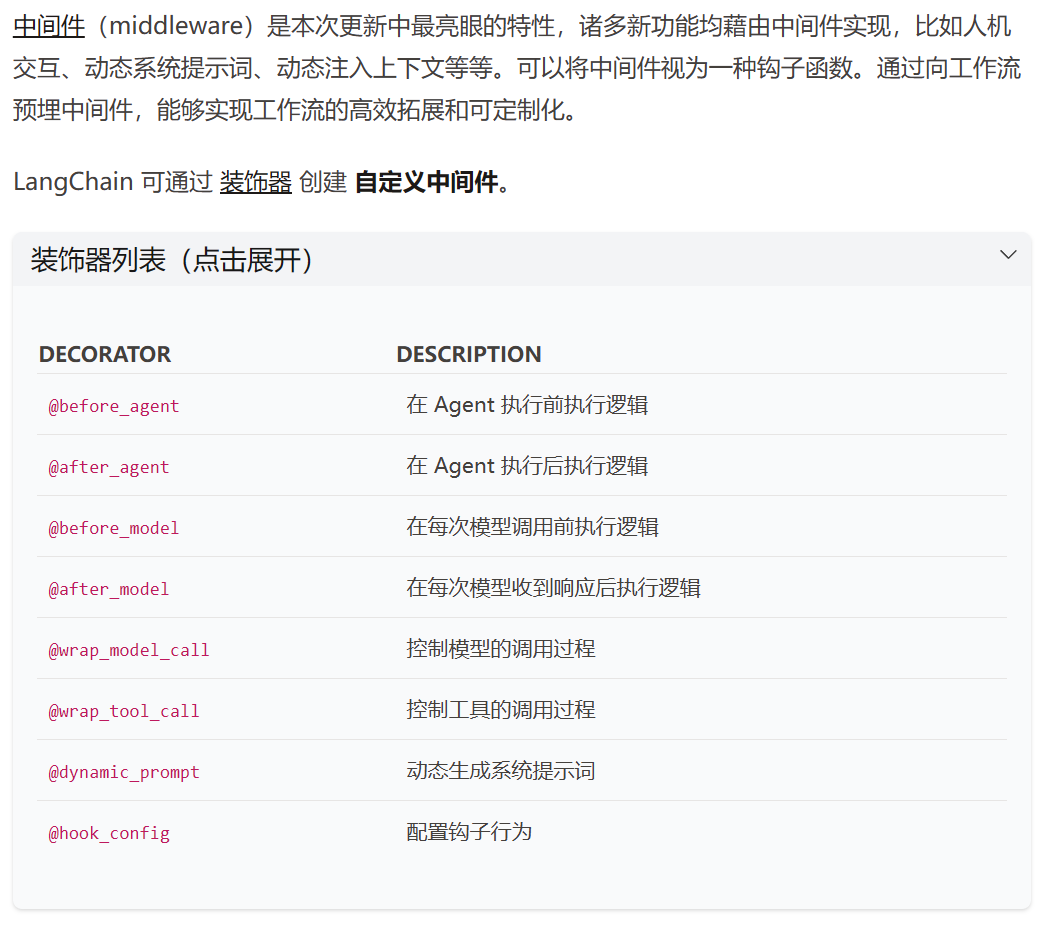

# 第一个例子：预算控制（@wrap_model_call）

使用了@wrap_model_call中间件，修改model中的逻辑

In [2]:
from dotenv import load_dotenv

# 从.env中引入宏参数
load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI
import os 

# LLM api
basic_model = ChatOpenAI(
    api_key = os.getenv("DASHSCOPE_API_KEY"),
    base_url = os.getenv("DASHSCOPE_BASE_URL"),
    model = "qwen3-coder-plus"
)

# 高费率模型
advanced_model = ChatOpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    model="qwen3-max",
)

这里修改了模型推理本身，因此只能使用 @wrap_model_call 

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.agents import create_agent

@wrap_model_call
def dynamic_model_selection(request : ModelRequest, handler) -> ModelResponse:
    """Choose model based on conversation complexity."""
    message_count = len(request.state["messages"])
    
    if message_count > 5:
        model = basic_model
    else:
        model = advanced_model
        
    request.model = model
    print(f"message_count: {message_count}")
    print(f"model_name: {model.model_name}")
    
    # 中间处理后再把request重新给handler
    return handler(request)
    
    
agent = create_agent(
    model = advanced_model, # 默认选择高级模型 
    middleware = [dynamic_model_selection] # 组装middleware
)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage

state : MessagesState = {"messages" : []} # 创建MessagesState，用于存储上下文
items = ['汽车', '飞机', '摩托车', '自行车']

for idx, item in enumerate(items):
    print(f"\n=== Round {idx+1} ===")
    state["messages"] += [HumanMessage(f"{item}有几个轮子，请简单回答")]
    result = agent.invoke(state)
    state["messages"] = result["messages"]
    print(f'content: {result["messages"][-1].content}')


=== Round 1 ===
message_count: 1
model_name: qwen3-max


C:\Users\bbfss\AppData\Local\Temp\ipykernel_5168\2960632856.py:14: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = model


content: 普通汽车有4个轮子。

=== Round 2 ===
message_count: 3
model_name: qwen3-max


C:\Users\bbfss\AppData\Local\Temp\ipykernel_5168\2960632856.py:14: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = model


content: 飞机通常有3个或更多轮子，常见的是2个主轮加1个前轮（共3个），大型客机可能有更多。

=== Round 3 ===
message_count: 5
model_name: qwen3-max


C:\Users\bbfss\AppData\Local\Temp\ipykernel_5168\2960632856.py:14: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = model


content: 摩托车有2个轮子。

=== Round 4 ===
message_count: 7
model_name: qwen3-coder-plus


C:\Users\bbfss\AppData\Local\Temp\ipykernel_5168\2960632856.py:14: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = model


content: 自行车有2个轮子。


: 

# 第二个例子：消息截断（@before_model）

消息截断功能可以通过 @before_model 装饰器实现。

In [4]:
from langchain.agents.middleware import before_model
from langchain.agents import create_agent, AgentState
from langgraph.runtime import Runtime
from typing import Any
from langchain.messages import RemoveMessage
from langgraph.graph.message import REMOVE_ALL_MESSAGES
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig


@before_model
def trim_messages(agentstate: AgentState, runtime : Runtime) -> dict [str, Any] | None :
    "信息的长度永远保持两条一下"
    messages = agentstate["messages"]
    if len(messages) <= 2:
        return None  # No changes needed
    
    return {
        "messages":[
            RemoveMessage(id = REMOVE_ALL_MESSAGES), #默认是追加模式，所以这里先移除所有消息，再把后面两条信息重新加入进去
            *messages[-2:]
        ]
    }

agent = create_agent(
    basic_model,
    middleware=[trim_messages], # 插入中间件
    checkpointer=InMemorySaver() # InMemorySaver 会把图（Graph）每一步执行后的状态都像快照（Snapshot）一样保存下来，所以你可以随时查看 Agent 在历史某一步到底在想什么、生成了什么数据。
)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}

In [5]:
agent.invoke({"messages": "hi, my name is bob"}, config)
agent.invoke({"messages": "write a short poem about cats"}, config)
agent.invoke({"messages": "now do the same but for dogs"}, config)
final_response = agent.invoke({"messages": "what's my name?"}, config)

In [9]:
final_response["messages"][-1].pretty_print()

================================== Ai Message ==================================

I don't have access to your name or any personal information about you. Each time you interact with me, I only see the current conversation - I can't recall previous interactions or personal details from other sessions. 

If you'd like to tell me your name, I'd be happy to know it for this conversation!


接下来创建一个没有中间件拦截消息的Agent，你会发现他会记住我们的名字

In [11]:
agent = create_agent(
    basic_model,
    checkpointer=InMemorySaver() # InMemorySaver 会把图（Graph）每一步执行后的状态都像快照（Snapshot）一样保存下来，所以你可以随时查看 Agent 在历史某一步到底在想什么、生成了什么数据。
)

In [12]:
agent.invoke({"messages": "hi, my name is bob"}, config)
agent.invoke({"messages": "write a short poem about cats"}, config)
agent.invoke({"messages": "now do the same but for dogs"}, config)
final_response = agent.invoke({"messages": "what's my name?"}, config)

In [13]:
final_response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Bob! You told me "hi, my name is bob" at the beginning of our conversation.


# 第三个例子： 敏感词过滤

我们可以使用中间件的方式完成敏感词过滤 

In [ ]:
from typing import Any

from langchain.agents.middleware import before_agent, AgentState
from langgraph.runtime import Runtime

banned_keywords = ["hack", "exploit", "malware"]

@before_agent
def content_filter(state : AgentState, runtime: Runtime) -> dict [str, Any] | None:
    """Deterministic guardrail: Block requests containing banned keywords."""
    # 第一条message
    if not state["messages"] : return None
    
    last_message = state["messages"][-1]
    if last_message.type != "human": return None
    
    lower_content = last_message.content.lower()
    
    # 开始检查铭感词
    for keyword in banned_keywords:
        if keyword in lower_content:
            return {
                
                "messages":[{
                    "role" : "assistant",
                    "content": "I cannot process requests containing inappropriate content. Please rephrase your request."
                }], # 这里提前拦截
                "jump_to" : "end"
            }
            
    return None

In [15]:
agent = create_agent(
    model = basic_model,
    middleware = [content_filter],
    )

result = agent.invoke({
    "messages": [{"role": "user", "content": "How do I hack into a database?"}]
})

In [16]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

How do I hack into a database?
================================== Ai Message ==================================

I cannot process requests containing inappropriate content. Please rephrase your request.
================================== Ai Message ==================================

If you are interested in database technology, here are some legal and ethical learning directions:

1. **Database Basics**
- Learn SQL syntax (MySQL, PostgreSQL, etc.)
- Understanding database design principles
- Master CRUD (add, delete, change, check) operations

2. **Safe Hands-on Lab Setup**
- Install local database environment (e.g. XAMPP/WAMP)
- Use tools such as phpMyAdmin to practice management
- Try importing and exporting sample data sets

3. **Legal Path to Learn Security**
- Learn penetration testing with authorization
- CTF (Capture The Flag) competition exercises
- Simulation platform (e. g. VulnHub, Hack The Bo

# 第四个例子：PII检测 

这里的基本的逻辑是 message_with_pii 函数里面会有输入， 然后装备了content_blocker，所以因为content blocker是before agent，所以这里他会在大模型处理输入前提前拦截 ： 

这里的逻辑是pii_agent会根据要求提前判断是否存在敏感信息，然后返回一个Ture or False

然后根据这个返回的来的结果，继续决定是否直接拦截请求

In [ ]:
from textwrap import dedent
from pydantic import BaseModel, Field

# 可信任的模型，一般是本地模型，为了方便，这里依然使用qwen
trusted_model = ChatOpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    model="qwen3-coder-plus",
)

# 告诉模型，检查完后必须按照这个格式给我报告：要么 True，要么 False
# 这里在创建的agent的response_format时候传入就行
class PiiCheck(BaseModel):
    is_pii: bool = Field(description="Whether the text contains PII")
    
def message_with_pii(pii_middleware):
    agent = create_agent(
        model = basic_model,
        middleware=[pii_middleware]
    )
    
    # This request will be blocked before any processing
    result = agent.invoke({
        "messages" : [{
            "role":"user",
            "content" : dedent(
                """
                File "/home/luochang/proj/agent.py", line 53, in my_agent
                    agent = create_react_agent(
                            ^^^^^^^^^^^^^^^^^^^
                File "/home/luochang/miniconda3/lib/python3.12/site-packages/typing_extensions.py", line 2950, in wrapper
                    return arg(*args, **kwargs)
                        ^^^^^^^^^^^^^^^^^^^^
                File "/home/luochang/miniconda3/lib/python3.12/site-packages/langgraph/prebuilt/chat_agent_executor.py", line 566, in create_react_agent
                    model = cast(BaseChatModel, model).bind_tools(
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                AttributeError: 'RunnableLambda' object has no attribute 'bind_tools'
    
                ---
    
                为啥报错
                """).strip()
        }]
    })

    return result


In [28]:
@before_agent(can_jump_to=["end"])
def content_blocker(state: AgentState,  runtime: Runtime) -> dict[str, Any] | None:
    """Deterministic guardrail: Block requests containing banned keywords."""
    # Get the first user message
    if not state["messages"]:
        return None

    last_message = state["messages"][-1]
    if last_message.type != "human":
        return None

    content = last_message.content.lower()
    prompt = (
        "你是一个隐私保护助手。请识别下面文本中涉及个人可识别信息（PII），"
        "例如：姓名、身份证号、护照号、电话号码、邮箱、住址、银行卡号、社交账号、车牌等。"
        "特别注意，若代码、文件路径中包含用户名，也应被视为敏感信息。"
        "若包含敏感信息，请返回{\"is_pii\": True}，否则返回{\"is_pii\": False}。"
        "请严格以 json 格式返回，并且只输出 json。文本如下：\n\n" + content
    )

    pii_agent = trusted_model.with_structured_output(PiiCheck)
    result = pii_agent.invoke(prompt)
    print(f"打印下结果{result}")
    if result.is_pii is True:
        # Block execution before any processing
        return {
            "messages": [{
                "role": "assistant",
                "content": "I cannot process requests containing inappropriate content. Please rephrase your request."
            }],
            "jump_to": "end"
        }
    else:
        print("No PII found")

    return None

In [29]:
result = message_with_pii(pii_middleware=content_blocker)

for message in result["messages"]:
    message.pretty_print()

打印下结果is_pii=True
================================ Human Message =================================

File "/home/luochang/proj/agent.py", line 53, in my_agent
    agent = create_react_agent(
            ^^^^^^^^^^^^^^^^^^^
File "/home/luochang/miniconda3/lib/python3.12/site-packages/typing_extensions.py", line 2950, in wrapper
    return arg(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^
File "/home/luochang/miniconda3/lib/python3.12/site-packages/langgraph/prebuilt/chat_agent_executor.py", line 566, in create_react_agent
    model = cast(BaseChatModel, model).bind_tools(
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'RunnableLambda' object has no attribute 'bind_tools'

---

为啥报错
================================== Ai Message ==================================

I cannot process requests containing inappropriate content. Please rephrase your request.
